# Trabalho de Inteligência Artificial - CNN para GTSRB

### Baseline: CNN simples para classificação de placas de trânsito

### 1. Setup

In [76]:
#!/usr/bin/env python3
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from src.gtsrb import NUM_CLASSES, GTSRB_CLASSES, get_dataloaders, save_predictions

In [77]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### 2. Funções de treino e avaliação

In [78]:
def train(trainloader,model,criterion,optimizer,device) -> tuple[float,float]:
    total_loss,correct,total  = 0.0, 0, 0

    for images, labels in trainloader:
      images, labels = images.to(device), labels.to(device)

      optimizer.zero_grad()
      outputs = model(images)
      loss = criterion(outputs, labels)
      loss.backward()
      optimizer.step()

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

    return total_loss/total, correct/total

def validate(val_loader,model,device) -> tuple[float,float]:
  total_loss,correct,total  = 0.0, 0, 0

  with torch.no_grad():
    for images, labels in val_loader:
      images, labels = images.to(device), labels.to(device)

      outputs = model(images)
      loss = criterion(outputs, labels)

      total_loss += loss.item() * images.size(0)
      correct += (outputs.argmax(dim=1) == labels).sum().item()
      total += labels.size(0)

  return total_loss/total, correct/total

### Funções de salvamento e carregamento de modelos

In [79]:
def save_mode_state(model,file_name,path='/content/drive/MyDrive/trabalho-ia-gtsrb-cnn'):
  PATH = f'{path}{file_name}'
  torch.save(model.state_dict(),PATH)

In [80]:
def load_model(file_name,path='/content/drive/MyDrive/trabalho-ia-gtsrb-cnn'):
  PATH = f'{path}{file_name}'
  model = EHMNet()
  model.load_state_dict(torch.load(PATH))
  return model

### Criando Classe para Rede Neural

In [81]:
# Classe do Modelo
class EHMNet(nn.Module):
  def __init__(self, num_classes:int = 43, img_size:int = 32):
    super(EHMNet,self).__init__()
    self.conv1 = nn.Conv2d(in_channels=3,out_channels=32,kernel_size=3,stride=1,padding='same')
    self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2)
    self.conv2 = nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,stride=1,padding='same')
    self.pool2 = nn.MaxPool2d(kernel_size=2,stride=2)

    spatial = img_size // 4
    flatten_size = 64 * spatial * spatial
    self.fc1 = nn.Linear(in_features=flatten_size,out_features=256)
    self.fc2 = nn.Linear(in_features=256,out_features=num_classes)

  def forward(self,x):
    x = self.conv1(x)
    x = torch.relu(x)
    x = self.pool1(x)

    x = self.conv2(x)
    x = torch.relu(x)
    x = self.pool2(x)

    x = torch.flatten(x,1)

    x = self.fc1(x)
    x = torch.relu(x)
    x = self.fc2(x)

    return x

##2. Hiperparâmetros e carregamento dos dados

In [82]:
# 1) Hiperparâmetros
IMG_SIZE = 32
BATCH_SIZE = 128
NUM_EPOCHS = 40
LR = 0.001
MOMENTUM = 0.9

# 1.1) Dados — o split ja vem fixo, basta chamar:
train_loader, val_loader, test_loader = get_dataloaders(img_size=IMG_SIZE, batch_size=BATCH_SIZE)

In [83]:
# Explorando o dataset de treino
print(f"NUM_CLASSES = {NUM_CLASSES}")
print(f"train_loader = {len(train_loader)} batches")
print(f"val_loader = {len(val_loader)} batches")
print(f"test_loader = {len(test_loader)} batches")

print("\nTrain")
for x,y in train_loader:
  print(x.shape)
  print(y.shape)
  break

print("\nValidatoin")
for x,y in val_loader:
  print(x.shape)
  print(y.shape)
  break

print("\nTest")
for x,y in test_loader:
  print(x.shape)
  print(y.shape)
  break

NUM_CLASSES = 43
train_loader = 167 batches
val_loader = 42 batches
test_loader = 99 batches

Train
torch.Size([128, 3, 32, 32])
torch.Size([128])

Validatoin
torch.Size([128, 3, 32, 32])
torch.Size([128])

Test
torch.Size([128, 3, 32, 32])
torch.Size([128])


### 3. Treinamento

In [84]:
# Estruturas para armazenar e comparar melhores modelos
best_models = {
    "sgd": {
        "acc": 0.0,
        "model": None,
        "history_loss_train": [],
        "history_loss_val": [],
        "history_acc_train": [],
        "history_acc_val": [],
        "cm": None
    },
    "sgd_momentum": {
        "acc": 0.0,
        "model": None,
        "history_loss_train": [],
        "history_loss_val": [],
        "history_acc_train": [],
        "history_acc_val": [],
        "cm": None
    },
    "adam": {
        "acc": 0.0,
        "model": None,
        "history_loss_train": [],
        "history_loss_val": [],
        "history_acc_train": [],
        "history_acc_val": [],
        "cm": None
    }
}

# Definindo dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### Executando testes com optimizer SGD

In [85]:
# 2) Seu modelo — implemente aqui
model = EHMNet().to(device)
if torch.cuda.is_available():
  print("Using GPU")
else:
  print("Using CPU")

Using GPU


In [86]:
# 3) Seu treino — implemente aqui
flag_model = "sgd"
file_name = "best_sgd_gtsrb_model.pth"

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR)

# Laço de treinamento
for e in range(NUM_EPOCHS):
  train_loss, train_acc = train(train_loader,model,criterion,optimizer,device)
  val_loss, val_acc = validate(val_loader,model,device)

  if val_acc > best_models[flag_model]["acc"]:
    best_models[flag_model]["acc"] = val_acc
    best_models[flag_model]["model"] = model

  best_models[flag_model]["history_loss_train"].append(train_loss)
  best_models[flag_model]["history_loss_val"].append(val_loss)
  best_models[flag_model]["history_acc_train"].append(train_acc)
  best_models[flag_model]["history_acc_val"].append(val_acc)

  if (e+1) % (NUM_EPOCHS/10) == 0:
    print(f"Epoch {(e+1):02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

save_mode_state(best_models[flag_model]["model"],file_name)

Epoch 04/40 | Train Loss: 3.6200 | Train Acc: 0.0602 | Val Loss: 3.5930 | Val Acc: 0.0572
Epoch 08/40 | Train Loss: 3.4182 | Train Acc: 0.1249 | Val Loss: 3.4031 | Val Acc: 0.1310
Epoch 12/40 | Train Loss: 3.2945 | Train Acc: 0.1388 | Val Loss: 3.2863 | Val Acc: 0.1451
Epoch 16/40 | Train Loss: 3.1868 | Train Acc: 0.1814 | Val Loss: 3.1761 | Val Acc: 0.1849
Epoch 20/40 | Train Loss: 3.0345 | Train Acc: 0.2294 | Val Loss: 3.0234 | Val Acc: 0.2262
Epoch 24/40 | Train Loss: 2.8215 | Train Acc: 0.2783 | Val Loss: 2.8102 | Val Acc: 0.2868
Epoch 28/40 | Train Loss: 2.5763 | Train Acc: 0.3304 | Val Loss: 2.5714 | Val Acc: 0.3273
Epoch 32/40 | Train Loss: 2.3272 | Train Acc: 0.3877 | Val Loss: 2.3402 | Val Acc: 0.3885
Epoch 36/40 | Train Loss: 2.0881 | Train Acc: 0.4537 | Val Loss: 2.0930 | Val Acc: 0.4531
Epoch 40/40 | Train Loss: 1.8765 | Train Acc: 0.5114 | Val Loss: 1.9393 | Val Acc: 0.4827


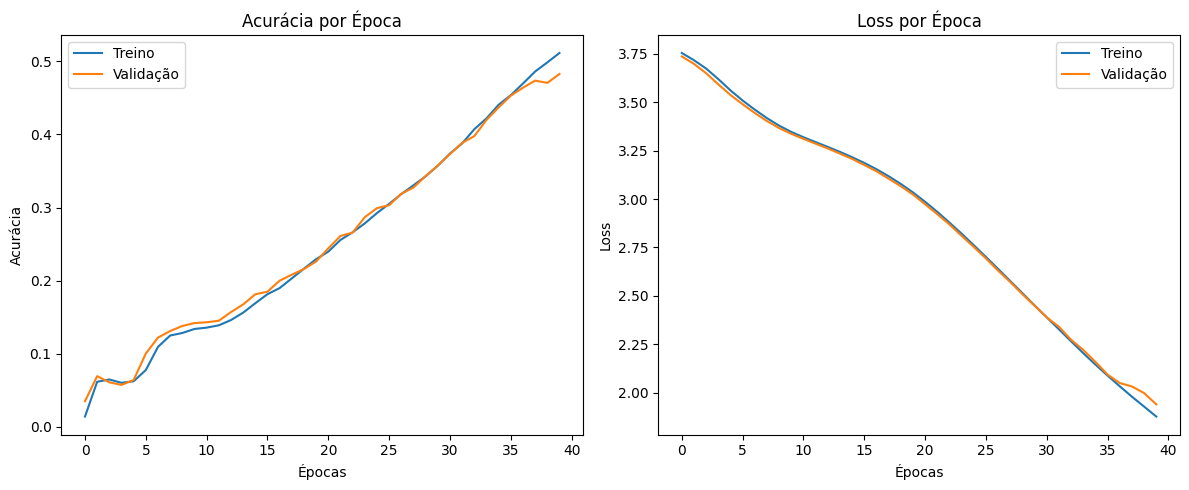

In [87]:
# Plotando Histórico da Loss e Acurácia
plot_history_metrics({
    "train": best_models[flag_model]["history_acc_train"],
    "val": best_models[flag_model]["history_acc_val"]},
    {
    "train": best_models[flag_model]["history_loss_train"],
    "val": best_models[flag_model]["history_loss_val"]
})


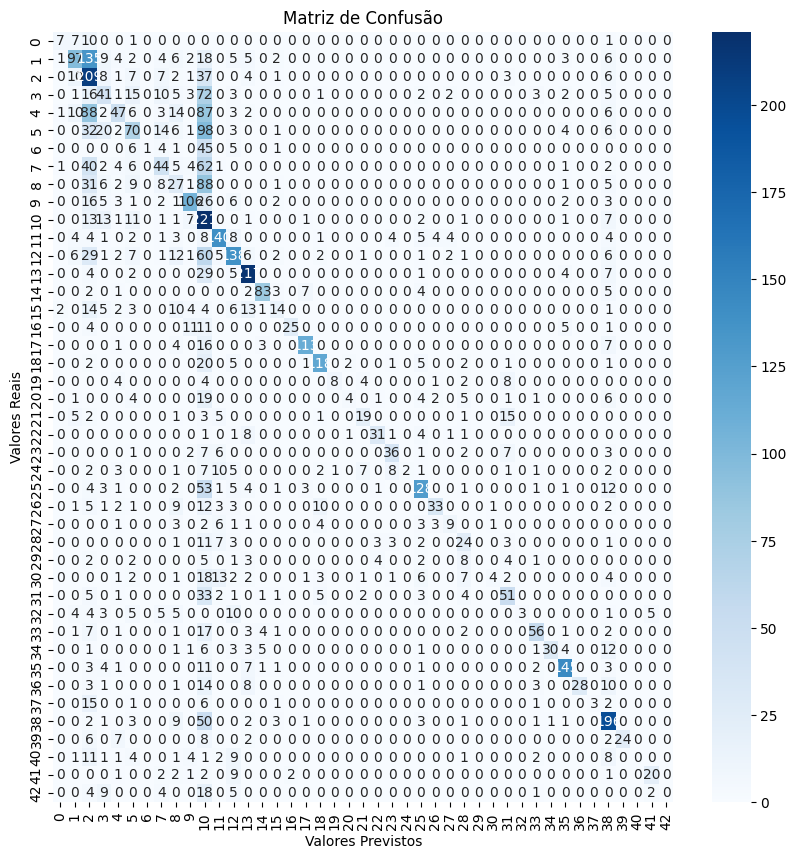

In [88]:
# Calculando e plotando matriz de confusão
cm = get_confusion_matrix(val_loader,NUM_CLASSES,model)
plot_confusion_matrix(cm)

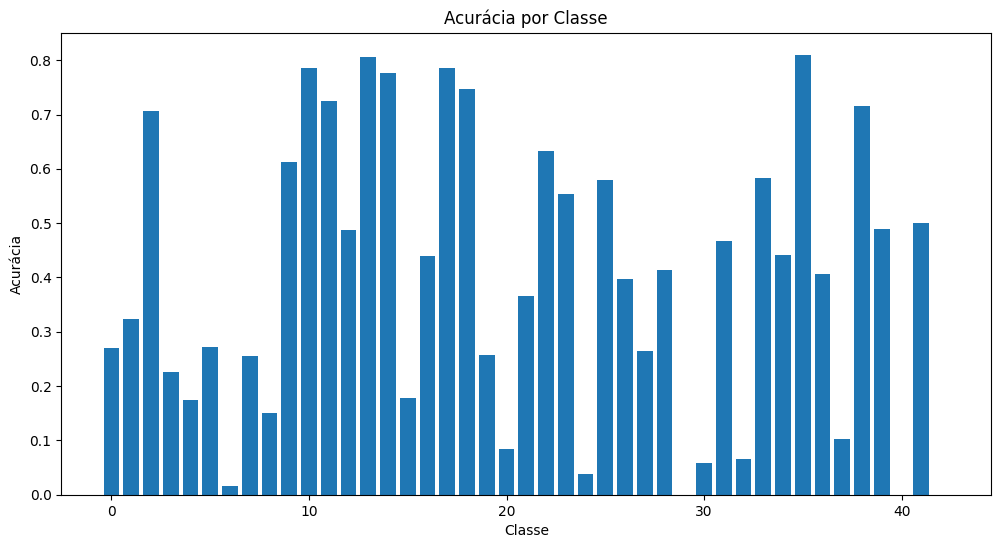

In [89]:
# Calculando e plotando acurácia por classe
acc_by_class = get_acc_by_class(cm)
plot_acc_by_class(acc_by_class)

In [90]:
# Carregando melhor modelo e avaliando acurácia
model = load_model(file_name)
model.to(device)

model.eval()
_, val_acc = validate(val_loader,model,device)
print(f"Val Acc: {val_acc:.4f}")

Val Acc: 0.4827


### Executando testes com optimizer SGD com momentun

In [91]:
# 2) Seu modelo — implemente aqui
model = EHMNet().to(device)
if torch.cuda.is_available():
  print("Using GPU")
else:
  print("Using CPU")

Using GPU


In [92]:
# 3) Seu treino — implemente aqui
flag_model = "sgd_momentum"
file_name = "best_sgd_momentum_gtsrb_model.pth"

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LR, momentum=MOMENTUM)

# Laço de treinamento
for e in range(NUM_EPOCHS):
  train_loss, train_acc = train(train_loader,model,criterion,optimizer,device)
  val_loss, val_acc = validate(val_loader,model,device)

  if val_acc > best_models[flag_model]["acc"]:
    best_models[flag_model]["acc"] = val_acc
    best_models[flag_model]["model"] = model

  best_models[flag_model]["history_loss_train"].append(train_loss)
  best_models[flag_model]["history_loss_val"].append(val_loss)
  best_models[flag_model]["history_acc_train"].append(train_acc)
  best_models[flag_model]["history_acc_val"].append(val_acc)

  if (e+1) % (NUM_EPOCHS/10) == 0:
    print(f"Epoch {(e+1):02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

save_mode_state(best_models[flag_model]["model"],file_name)

Epoch 04/40 | Train Loss: 2.4225 | Train Acc: 0.3629 | Val Loss: 2.1577 | Val Acc: 0.4221
Epoch 08/40 | Train Loss: 0.9124 | Train Acc: 0.7334 | Val Loss: 0.8545 | Val Acc: 0.7468
Epoch 12/40 | Train Loss: 0.5030 | Train Acc: 0.8531 | Val Loss: 0.5147 | Val Acc: 0.8455
Epoch 16/40 | Train Loss: 0.3254 | Train Acc: 0.9105 | Val Loss: 0.3304 | Val Acc: 0.9127
Epoch 20/40 | Train Loss: 0.2067 | Train Acc: 0.9465 | Val Loss: 0.2417 | Val Acc: 0.9328
Epoch 24/40 | Train Loss: 0.1503 | Train Acc: 0.9619 | Val Loss: 0.1980 | Val Acc: 0.9474
Epoch 28/40 | Train Loss: 0.1089 | Train Acc: 0.9753 | Val Loss: 0.1645 | Val Acc: 0.9574
Epoch 32/40 | Train Loss: 0.0878 | Train Acc: 0.9794 | Val Loss: 0.1349 | Val Acc: 0.9664
Epoch 36/40 | Train Loss: 0.0749 | Train Acc: 0.9814 | Val Loss: 0.1528 | Val Acc: 0.9574
Epoch 40/40 | Train Loss: 0.0574 | Train Acc: 0.9873 | Val Loss: 0.1763 | Val Acc: 0.9523


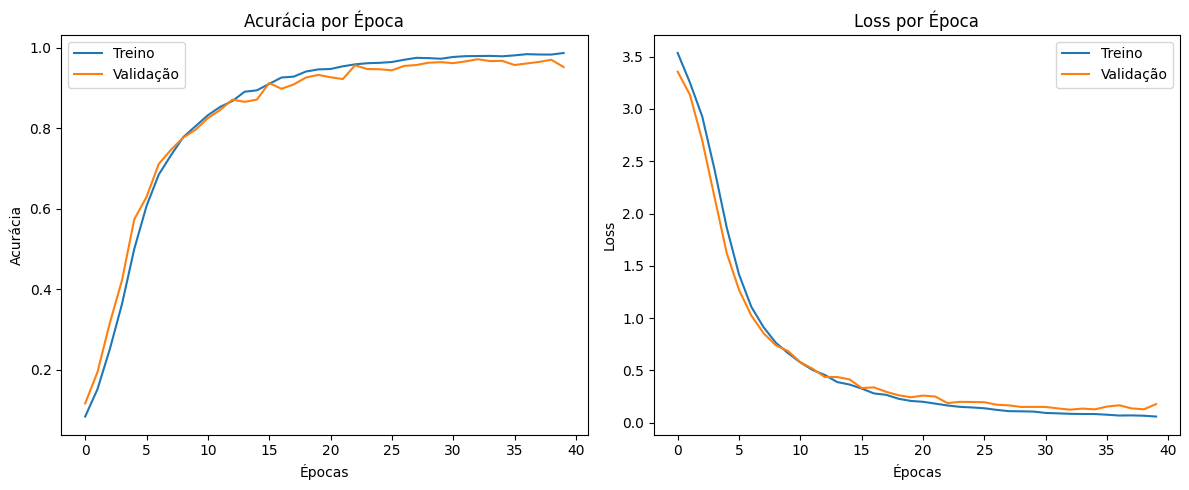

In [93]:
# Plotando Histórico da Loss e Acurácia
plot_history_metrics({
    "train": best_models[flag_model]["history_acc_train"],
    "val": best_models[flag_model]["history_acc_val"]},
    {
    "train": best_models[flag_model]["history_loss_train"],
    "val": best_models[flag_model]["history_loss_val"]
})

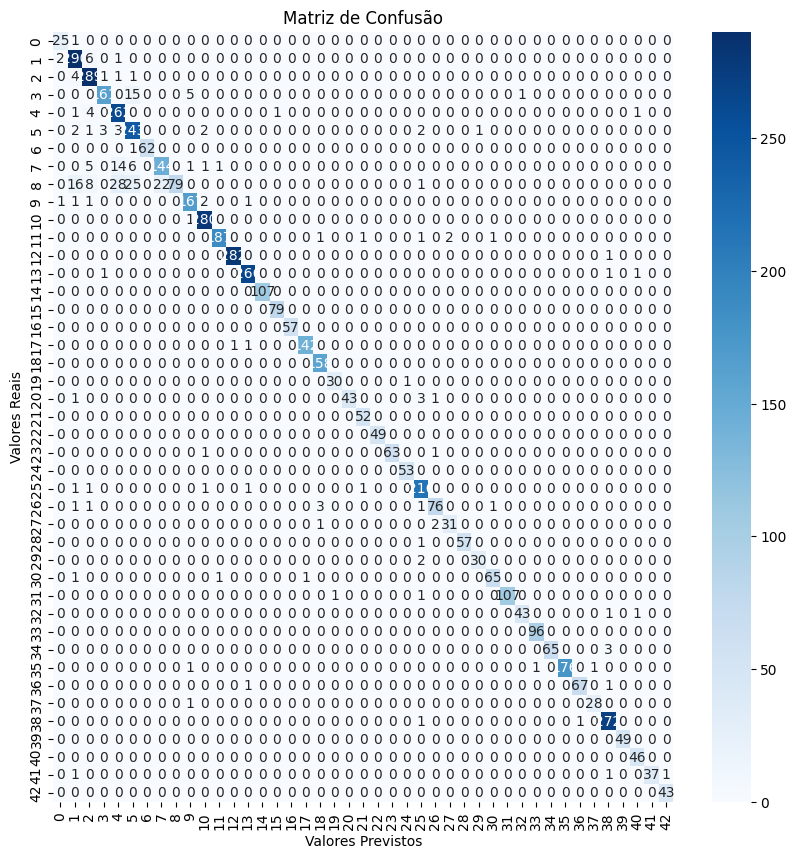

In [94]:
# Calculando e plotando matriz de confusão
cm = get_confusion_matrix(val_loader,NUM_CLASSES,model)
plot_confusion_matrix(cm)

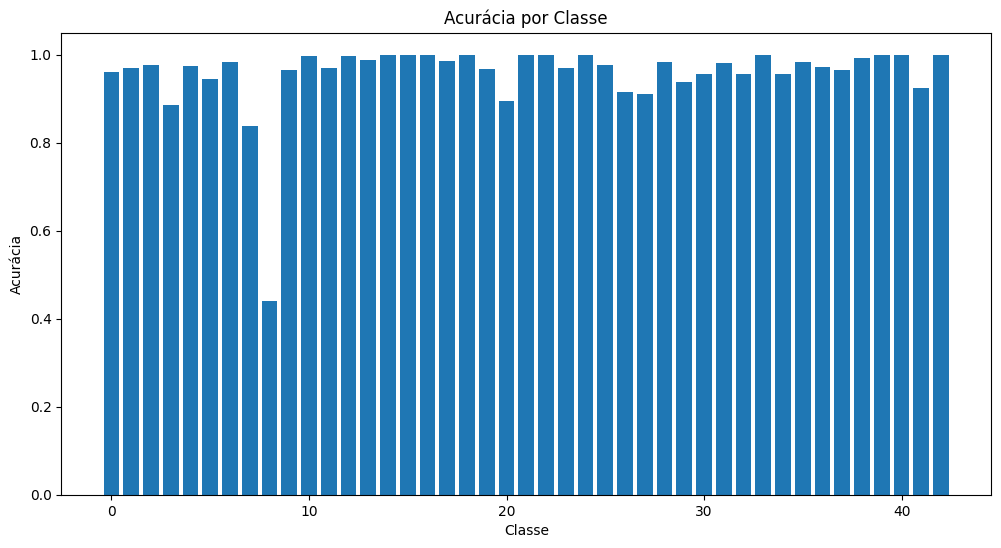

In [95]:
# Calculando e plotando acurácia por classe
acc_by_class = get_acc_by_class(cm)
plot_acc_by_class(acc_by_class)

In [96]:
# Carregando melhor modelo e avaliando acurácia
file_name = "best_sgd_momentum_gtsrb_model.pth"

model = load_model(file_name)
model.to(device)

model.eval()
_, val_acc = validate(val_loader,model,device)
print(f"Val Acc: {val_acc:.4f}")

Val Acc: 0.9523


### Executando testes com optimizer Adam

In [97]:
# 2) Seu modelo — implemente aqui
model = EHMNet().to(device)
if torch.cuda.is_available():
  print("Using GPU")
else:
  print("Using CPU")

Using GPU


In [98]:
# 3) Seu treino — implemente aqui
flag_model = "adam"
file_name = "best_adam_gtsrb_model.pth"

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

# Laço de treinamento
for e in range(NUM_EPOCHS):
  train_loss, train_acc = train(train_loader,model,criterion,optimizer,device)
  val_loss, val_acc = validate(val_loader,model,device)

  if val_acc > best_models[flag_model]["acc"]:
    best_models[flag_model]["acc"] = val_acc
    best_models[flag_model]["model"] = model

  best_models[flag_model]["history_loss_train"].append(train_loss)
  best_models[flag_model]["history_loss_val"].append(val_loss)
  best_models[flag_model]["history_acc_train"].append(train_acc)
  best_models[flag_model]["history_acc_val"].append(val_acc)

  if (e+1) % (NUM_EPOCHS/10) == 0:
    print(f"Epoch {(e+1):02d}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

save_mode_state(best_models[flag_model]["model"],file_name)

Epoch 04/40 | Train Loss: 0.0617 | Train Acc: 0.9830 | Val Loss: 0.1146 | Val Acc: 0.9677
Epoch 08/40 | Train Loss: 0.0126 | Train Acc: 0.9973 | Val Loss: 0.0383 | Val Acc: 0.9912
Epoch 12/40 | Train Loss: 0.0173 | Train Acc: 0.9944 | Val Loss: 0.0503 | Val Acc: 0.9882
Epoch 16/40 | Train Loss: 0.0035 | Train Acc: 0.9991 | Val Loss: 0.0438 | Val Acc: 0.9940
Epoch 20/40 | Train Loss: 0.0009 | Train Acc: 0.9998 | Val Loss: 0.0637 | Val Acc: 0.9886
Epoch 24/40 | Train Loss: 0.0021 | Train Acc: 0.9996 | Val Loss: 0.0371 | Val Acc: 0.9942
Epoch 28/40 | Train Loss: 0.0001 | Train Acc: 1.0000 | Val Loss: 0.0388 | Val Acc: 0.9951
Epoch 32/40 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0415 | Val Acc: 0.9951
Epoch 36/40 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0432 | Val Acc: 0.9951
Epoch 40/40 | Train Loss: 0.0000 | Train Acc: 1.0000 | Val Loss: 0.0445 | Val Acc: 0.9953


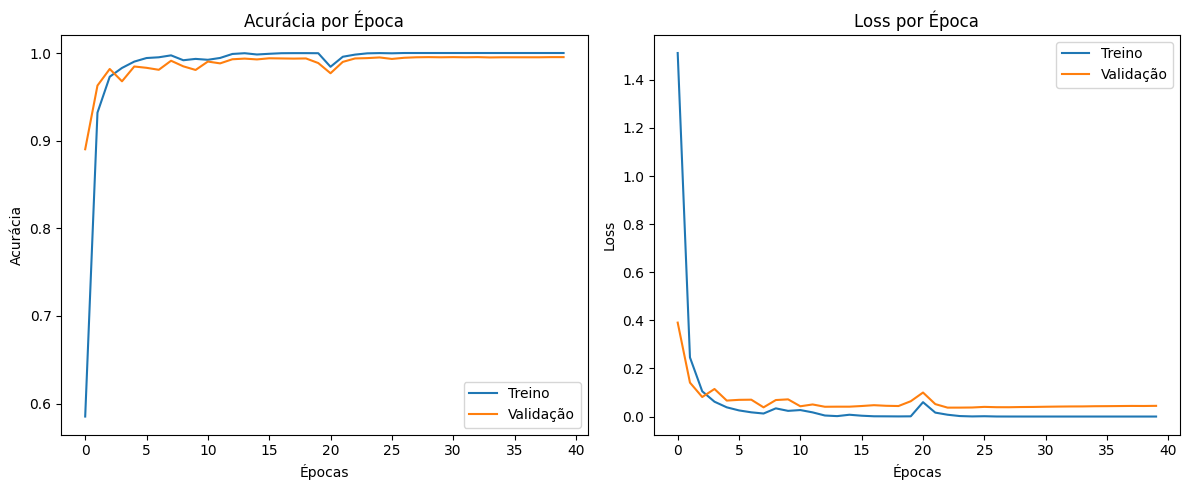

In [99]:
# Plotando Histórico da Loss e Acurácia
plot_history_metrics({
    "train": best_models[flag_model]["history_acc_train"],
    "val": best_models[flag_model]["history_acc_val"]},
    {
    "train": best_models[flag_model]["history_loss_train"],
    "val": best_models[flag_model]["history_loss_val"]
})

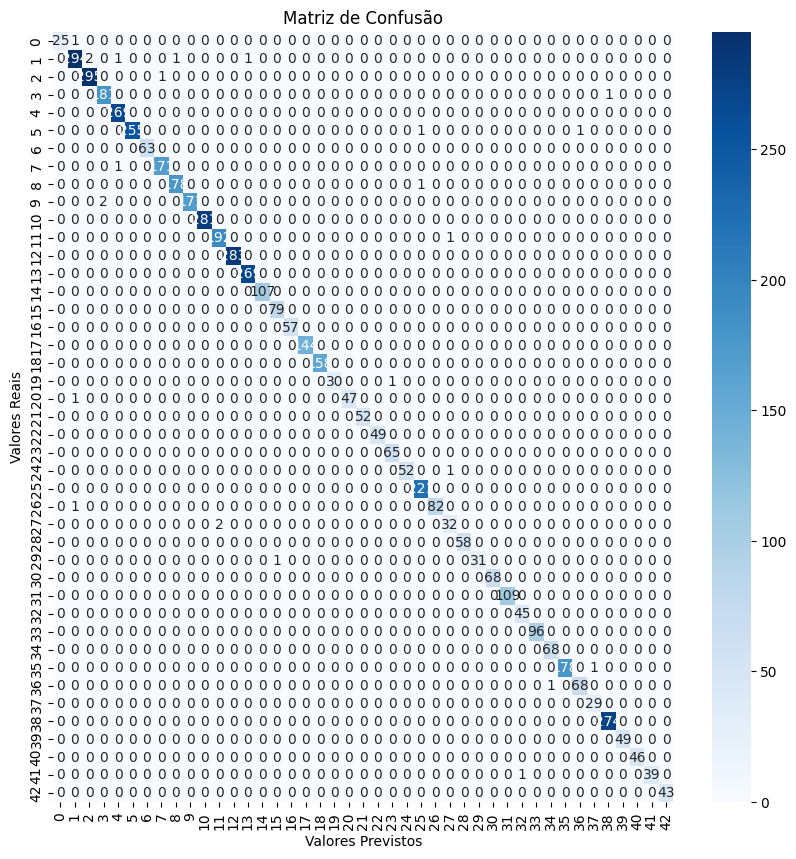

In [100]:
# Calculando e plotando matriz de confusão
cm = get_confusion_matrix(val_loader,NUM_CLASSES,model)
plot_confusion_matrix(cm)

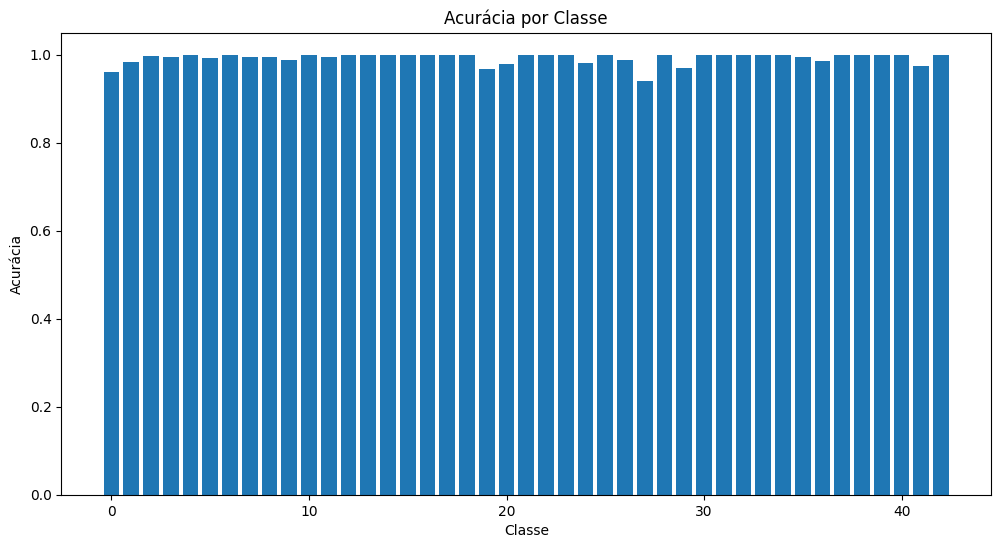

In [101]:
# Calculando e plotando acurácia por classe
acc_by_class = get_acc_by_class(cm)
plot_acc_by_class(acc_by_class)

In [102]:
# Carregando melhor modelo e avaliando acurácia
file_name = "best_adam_gtsrb_model.pth"

model = load_model(file_name)
model.to(device)

model.eval()
_, val_acc = validate(val_loader,model,device)
print(f"Val Acc: {val_acc:.4f}")

Val Acc: 0.9953


### 4. Avalição final geração dos arquivos

In [103]:
# Carregando melhor modelo
best_model_optimizer = max(best_models, key=lambda x: best_models[x]["acc"])
model = best_models[best_model_optimizer]["model"]
acc = best_models[best_model_optimizer]['acc']
print(f"Melhor modelo: {best_model_optimizer}")
print(f"Acurácia: {acc:.4f}")

Melhor modelo: adam
Acurácia: 0.9953


In [104]:
# 4) Avaliacao final e entrega
model.eval()
all_preds = []
with torch.no_grad():
    for images, _ in test_loader:
        outputs = model(images.to(device))
        all_preds.append(outputs.argmax(dim=1).cpu())
y_pred = torch.cat(all_preds)

In [105]:
# Gera o CSV para entrega — um por experimento
save_predictions(y_pred, "results/predicoes_baseline.csv", experiment_name="Baseline")
print(f"Predicoes salvas ({len(y_pred)} imagens)")

Predicoes salvas (12630 imagens)
